In [1]:
from sklearn.datasets import load_digits
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
digits = load_digits()

# See what's inside
print("Total images  :", digits.data.shape[0])
print("Total features:", digits.data.shape[1])
print("Digits (0-9)  :", digits.target_names)

Total images  : 1797
Total features: 64
Digits (0-9)  : [0 1 2 3 4 5 6 7 8 9]


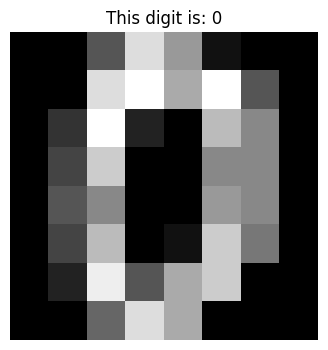

64 pixel values:
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


In [2]:
# See what a digit looks like
plt.figure(figsize=(4,4))
plt.imshow(digits.images[0], cmap='gray')
plt.title(f"This digit is: {digits.target[0]}")
plt.axis('off')
plt.show()

# See its 64 numbers
print("64 pixel values:")
print(digits.data[0])

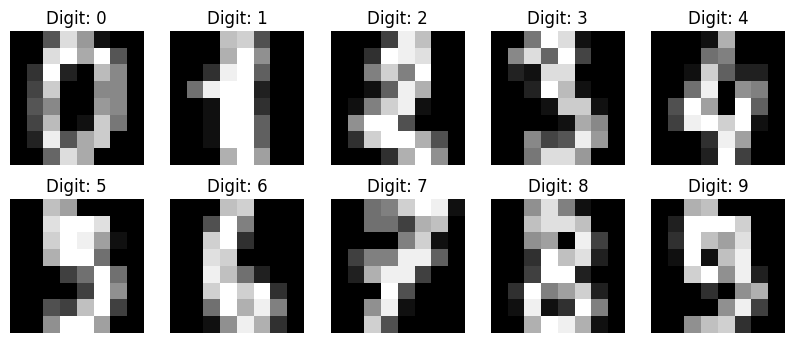

In [3]:
# See first 10 digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Digit: {digits.target[i]}")
    ax.axis('off')

plt.show()

In [4]:
from sklearn.model_selection import train_test_split

# Define input and output
X = digits.data    # 64 pixel values
y = digits.target  # correct digit (0-9)

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Total images   : {len(X)}")
print(f"Training images: {len(X_train)}")
print(f"Testing images : {len(X_test)}")

Total images   : 1797
Training images: 1437
Testing images : 360


In [5]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train SVM with RBF kernel
model_rbf = SVC(kernel='rbf')
model_rbf.fit(X_train, y_train)

# Predict and check accuracy
y_pred_rbf = model_rbf.predict(X_test)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

print(f"Accuracy with RBF kernel: {accuracy_rbf * 100:.2f}%")

Accuracy with RBF kernel: 98.61%


In [6]:
# Train SVM with Linear kernel
model_linear = SVC(kernel='linear')
model_linear.fit(X_train, y_train)

# Predict and check accuracy
y_pred_linear = model_linear.predict(X_test)
accuracy_linear = accuracy_score(y_test, y_pred_linear)

print(f"Accuracy with RBF kernel   : {accuracy_rbf * 100:.2f}%")
print(f"Accuracy with Linear kernel: {accuracy_linear * 100:.2f}%")

Accuracy with RBF kernel   : 98.61%
Accuracy with Linear kernel: 97.78%


In [7]:
# Try different C and gamma values
results = []

C_values     = [0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1]

for c in C_values:
    for g in gamma_values:
        model = SVC(kernel='rbf', C=c, gamma=g)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results.append((c, g, acc * 100))
        print(f"C={c}, gamma={g} → Accuracy: {acc * 100:.2f}%")

# Find best combination
best = max(results, key=lambda x: x[2])
print(f"\nBest combination:")
print(f"C={best[0]}, gamma={best[1]} → Accuracy: {best[2]:.2f}%")

C=0.1, gamma=0.001 → Accuracy: 96.67%
C=0.1, gamma=0.01 → Accuracy: 7.78%
C=0.1, gamma=0.1 → Accuracy: 7.78%
C=0.1, gamma=1 → Accuracy: 7.78%
C=1, gamma=0.001 → Accuracy: 98.89%
C=1, gamma=0.01 → Accuracy: 79.17%
C=1, gamma=0.1 → Accuracy: 7.78%
C=1, gamma=1 → Accuracy: 7.78%
C=10, gamma=0.001 → Accuracy: 98.89%
C=10, gamma=0.01 → Accuracy: 81.39%
C=10, gamma=0.1 → Accuracy: 7.78%
C=10, gamma=1 → Accuracy: 7.78%
C=100, gamma=0.001 → Accuracy: 98.89%
C=100, gamma=0.01 → Accuracy: 81.39%
C=100, gamma=0.1 → Accuracy: 7.78%
C=100, gamma=1 → Accuracy: 7.78%

Best combination:
C=1, gamma=0.001 → Accuracy: 98.89%
